# Lab 3: PyTorch for Cat vs Dog Faces

This notebook is the next step after Labs 1 and 2, but it is self-contained.

- Lab 1 worked with image arrays, normalization, and a hand-crafted feature matrix.
- Lab 2 worked with metadata tables, split handling, and label mapping in Pandas.
- Lab 3 turns the same kind of image workflow into PyTorch tensors, datasets, loaders, and a trainable CNN.

In this notebook, you will train a small **binary image classifier** with PyTorch.

We will focus on the core training pipeline:

- turning a metadata table into training inputs
- converting image files into PyTorch tensors
- building `Dataset` and `DataLoader` objects
- defining a simple CNN model
- choosing a loss and optimizer
- writing training and evaluation loops
- comparing learned features with handcrafted NumPy features from Lab 1

Set the fixed random seed `1234` in the first code cell. Each notebook uses it for sampling, split suggestions, and visualization so the results are reproducible.

**Questions in this lab**

1. Map labels to integers in the dataframe loaded in this notebook
2. Build a dataset that returns tensors
3. Create train, validation, and test DataLoaders
4. Inspect one mini-batch
5. Define a simple CNN classifier
6. Set up loss, optimizer, and device
7. Complete one training epoch
8. Evaluate the model on a validation or test loader
9. Train for a few epochs and compare it with the Lab 1 NumPy feature pipeline


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from lab_utils.visualization import (
    extract_feature_maps,
    plot_feature_maps_like_reference,
    plot_training_history,
    show_tensor_batch,
)

def find_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "data").exists():
            return candidate
    return Path.cwd().resolve()

PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
METADATA_PATH = DATA_ROOT / "metadata.csv"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

LABELS = ("cat", "dog")
SPLITS = ("train", "val", "test")
SEED = 1234
EPOCHS = 20
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
NUMPY_PRED_PATH = ARTIFACT_DIR / "lab3_pytorch_predictions.csv"

def seed_index(length: int, offset: int = 0) -> int:
    if length <= 0:
        raise ValueError("Cannot choose an index from an empty collection.")
    return int((SEED + offset) % length)

def build_metadata_from_folders(data_root: Path) -> pd.DataFrame:
    rows = []
    for split in SPLITS:
        for label in LABELS:
            label_dir = data_root / split / label
            for path in sorted(label_dir.glob("*.jpg")) + sorted(label_dir.glob("*.png")):
                with Image.open(path) as image:
                    image = image.convert("RGB")
                    width, height = image.size
                rows.append(
                    {
                        "filepath": str(path.relative_to(data_root)),
                        "label": label,
                        "split": split,
                        "width": width,
                        "height": height,
                    }
                )
    return pd.DataFrame(rows)

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        "Dataset not found. Place the prepared subset at data/."
    )

if METADATA_PATH.exists():
    df = pd.read_csv(METADATA_PATH)
else:
    df = build_metadata_from_folders(DATA_ROOT)

print(f"Fixed seed: {SEED}")
print(df.head())
print(df["split"].value_counts())


Fixed seed: 1234
                 filepath label  split  width  height
0  train/cat/cat_0000.jpg   cat  train     64      64
1  train/cat/cat_0001.jpg   cat  train     64      64
2  train/cat/cat_0002.jpg   cat  train     64      64
3  train/cat/cat_0003.jpg   cat  train     64      64
4  train/cat/cat_0004.jpg   cat  train     64      64
split
train    420
val       90
test      90
Name: count, dtype: int64


## Question 1: Turn string labels into integer labels

Complete `build_label_mapping(...)`.

It should:

- a dictionary `label_to_index`
- a dataframe with `label_id`
- train, validation, and test dataframes
- a new column `label_id`

Use `cat -> 0` and `dog -> 1`.

This is the same Pandas-style label handling from Lab 2, but now the labels become the targets for PyTorch training.


In [2]:
def build_label_mapping(frame: pd.DataFrame) -> tuple[dict[str, int], pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    label_to_index = {label: index for index, label in enumerate(LABELS)}
    labelled = frame.copy()
    labelled["label_id"] = labelled["label"].map(label_to_index).astype(int)
    train_df = labelled[labelled["split"] == "train"].reset_index(drop=True)
    val_df = labelled[labelled["split"] == "val"].reset_index(drop=True)
    test_df = labelled[labelled["split"] == "test"].reset_index(drop=True)
    return label_to_index, labelled, train_df, val_df, test_df


label_to_index, df, train_df, val_df, test_df = build_label_mapping(df)

print(label_to_index)
print(train_df.head())

assert set(label_to_index.keys()) == {"cat", "dog"}, "Both classes should appear in the mapping."


{'cat': 0, 'dog': 1}
                 filepath label  split  width  height  label_id
0  train/cat/cat_0000.jpg   cat  train     64      64         0
1  train/cat/cat_0001.jpg   cat  train     64      64         0
2  train/cat/cat_0002.jpg   cat  train     64      64         0
3  train/cat/cat_0003.jpg   cat  train     64      64         0
4  train/cat/cat_0004.jpg   cat  train     64      64         0


## Question 2: Build a dataset that returns tensors

In Lab 1, you turned images into NumPy arrays and normalized pixel values.
Now do the same preprocessing in PyTorch.

Complete:

- `image_to_tensor`
- `CatsDogsDataset.__getitem__`

Your dataset should return:

- an image tensor with shape `(3, 64, 64)`
- an integer label tensor


In [3]:
def image_to_tensor(path: Path) -> torch.Tensor:
    with Image.open(path) as image:
        image = image.convert("RGB").resize((64, 64))
        array = np.asarray(image, dtype=np.float32) / 255.0
    tensor = torch.from_numpy(array).permute(2, 0, 1).contiguous()
    return tensor

class CatsDogsDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, data_root: Path):
        self.frame = frame.reset_index(drop=True)
        self.data_root = data_root

    def __len__(self) -> int:
        return len(self.frame)

    def __getitem__(self, index: int):
        row = self.frame.iloc[index]
        image_tensor = image_to_tensor(Path(self.data_root) / row["filepath"])
        label_tensor = torch.tensor(int(row["label_id"]), dtype=torch.long)
        return image_tensor, label_tensor

train_dataset = CatsDogsDataset(train_df, DATA_ROOT)
first_image, first_label = train_dataset[0]
print(first_image.shape, first_image.dtype, first_label)


torch.Size([3, 64, 64]) torch.float32 tensor(0)


## Question 3: Create DataLoaders

Complete `build_dataloaders(...)`.

Turn the metadata table in this notebook into training inputs.

Build three DataLoaders:

- training loader with `shuffle=True`
- validation loader with `shuffle=False`
- test loader with `shuffle=False`

Use a batch size of `32`.

Reuse `train_df`, `val_df`, and `test_df` here.


In [4]:
BATCH_SIZE = 32
train_loader_generator = torch.Generator().manual_seed(SEED)

def build_dataloaders(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    test_df: pd.DataFrame,
    data_root: Path,
    batch_size: int = 32,
    seed: int = SEED,
    dataset_cls: type[Dataset] = CatsDogsDataset,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    train_dataset = dataset_cls(train_df, data_root)
    val_dataset = dataset_cls(val_df, data_root)
    test_dataset = dataset_cls(test_df, data_root)

    generator = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
    )
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_dataloaders(
    train_df,
    val_df,
    test_df,
    DATA_ROOT,
    batch_size=BATCH_SIZE,
    seed=SEED,
)

train_loader, val_loader, test_loader


(<torch.utils.data.dataloader.DataLoader at 0x7f72cd333450>,
 <torch.utils.data.dataloader.DataLoader at 0x7f72844c2d90>)

## Question 4: Inspect one mini-batch

Complete `inspect_first_batch(...)`.

Pull one batch from the training loader and verify:

- image batch shape
- label batch shape
- image dtype
- label dtype


Image batch: torch.Size([32, 3, 64, 64]) torch.float32
Label batch: torch.Size([32]) torch.int64


(<Figure size 1000x600 with 8 Axes>,
 array([[<Axes: title={'center': 'cat'}>, <Axes: title={'center': 'cat'}>,
         <Axes: title={'center': 'dog'}>, <Axes: title={'center': 'dog'}>],
        [<Axes: title={'center': 'cat'}>, <Axes: title={'center': 'dog'}>,
         <Axes: title={'center': 'cat'}>, <Axes: title={'center': 'dog'}>]],
       dtype=object))

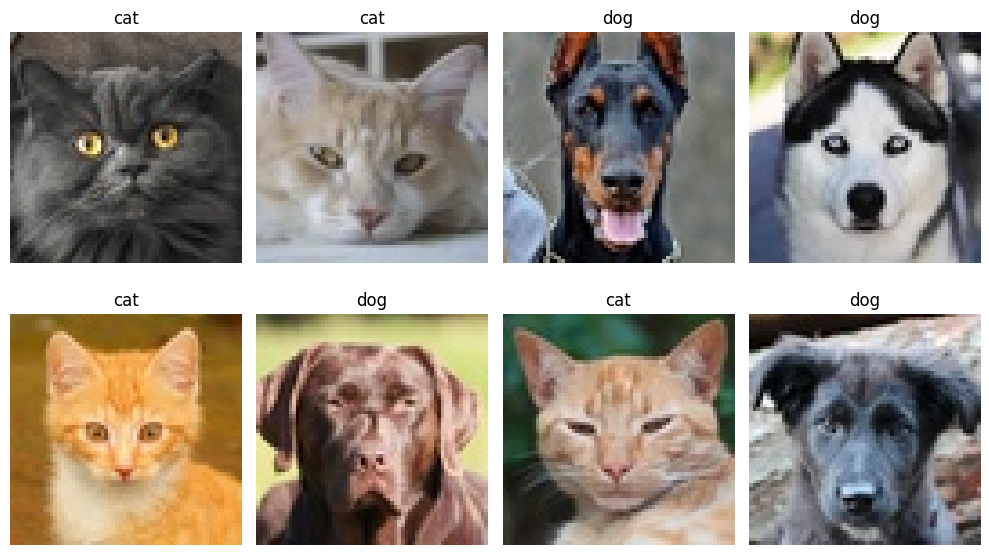

In [5]:
def inspect_first_batch(loader: DataLoader) -> tuple[torch.Tensor, torch.Tensor]:
    if loader is None:
        raise ValueError("Complete Question 3 before inspecting a batch.")

    batch_images, batch_labels = next(iter(loader))

    print("Image batch:", batch_images.shape, batch_images.dtype)
    print("Label batch:", batch_labels.shape, batch_labels.dtype)

    assert batch_images.ndim == 4, "Batches of images should have shape (B, C, H, W)."
    assert batch_images.shape[1] == 3, "Color images should have 3 channels."
    assert batch_labels.dtype == torch.long, "Labels should be torch.long class indices."
    return batch_images, batch_labels


batch_images, batch_labels = inspect_first_batch(train_loader)

show_tensor_batch(
    batch_images[:8].cpu().numpy(),
    batch_labels[:8].cpu().numpy(),
    class_names=LABELS,
    max_items=8,
    ncols=4,
)


## Shape checkpoint

Before moving on to the CNN, check that your mini-batch looks right:

- images: `(batch, 3, 64, 64)`
- labels: integer class IDs with dtype `torch.long`

If either one looks off, fix the dataset or preprocessing step before Question 5.


## Question 5: Define a simple CNN classifier

In Lab 1, the features were hand-crafted.
Here, the CNN learns its own features automatically.

Complete the model below.

Suggested architecture:

- stage 1: `Conv2d(3, 16, kernel_size=3, padding=1)` -> `ReLU` -> `MaxPool2d(2)`
- stage 2: `Conv2d(16, 32, kernel_size=3, padding=1)` -> `ReLU` -> `MaxPool2d(2)`
- classifier: `Flatten` -> `Linear(32 * 16 * 16, 64)` -> `ReLU` -> `Linear(64, 2)`


In [6]:
class CatsDogsSimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stage1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.stage2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.stage1(x)
        x = self.stage2(x)
        return self.classifier(x)


model = CatsDogsSimpleCNN()
example_logits = model(batch_images[:4])
print(example_logits.shape)

assert example_logits.shape == (4, 2), "The classifier should output two logits per image."


torch.Size([4, 2])


## Question 6: Set up the training ingredients

Complete `setup_training(...)`.

Choose:

- a device (`cuda` if available, otherwise `cpu`)
- a loss function
- an optimizer

Use `CrossEntropyLoss` and `Adam` for this lab.

Set the learning rate to `1e-3`.


In [7]:
def setup_training(
    model: nn.Module,
    device: torch.device | None = None,
    learning_rate: float = 1e-3,
) -> tuple[torch.device, nn.Module, nn.Module, torch.optim.Optimizer]:
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    return device, model, criterion, optimizer


device, model, criterion, optimizer = setup_training(model)

print("Using device:", device)


Using device: cpu


## Question 7: Complete one training epoch

Fill in the missing logic for:

- zeroing gradients
- forward pass
- loss computation
- backward pass
- optimizer step
- batch accuracy tracking


In [8]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        predictions = logits.argmax(dim=1)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_correct += int((predictions == labels).sum().item())
        total_examples += batch_size

    average_loss = total_loss / total_examples
    average_accuracy = total_correct / total_examples
    return average_loss, average_accuracy


## Question 8: Evaluate one model on one loader

Complete `evaluate(...)`.

It should run the model in evaluation mode on one loader and return average loss and accuracy.

Reflection prompts:

1. Did the simple CNN outperform the Lab 1 NumPy feature pipeline?
2. Did the model start to overfit?
3. What would you try next: horizontal flips, more filters, one more conv block, or longer training?
4. Why might learned features from a CNN outperform the handcrafted NumPy features from Lab 1?


In [9]:
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
) -> tuple[float, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)
            predictions = logits.argmax(dim=1)
            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += int((predictions == labels).sum().item())
            total_examples += batch_size

    average_loss = total_loss / total_examples
    average_accuracy = total_correct / total_examples
    return average_loss, average_accuracy

val_loss, val_acc = evaluate(model, val_loader, criterion, device)
print(f"Validation: loss={val_loss:.4f}, acc={val_acc:.3f}")


Validation: loss=0.6958, acc=0.500


## Question 9: Train for a few epochs and evaluate

Complete `run_training_experiment(...)`.

It should train for a few epochs, evaluate on the test set.

Reflection prompts:

1. Did the model start to overfit?
2. What would you try next: horizontal flips, more filters, one more conv block, or longer training?


Epoch 01: train_loss=0.6853, train_acc=0.529, val_loss=0.6544, val_acc=0.633


Epoch 02: train_loss=0.6075, train_acc=0.724, val_loss=0.5651, val_acc=0.711


Epoch 03: train_loss=0.4799, train_acc=0.783, val_loss=0.6174, val_acc=0.689


Epoch 04: train_loss=0.4342, train_acc=0.802, val_loss=0.4603, val_acc=0.811


Epoch 05: train_loss=0.3337, train_acc=0.857, val_loss=0.4497, val_acc=0.822


...

Epoch 17: train_loss=0.0158, train_acc=1.000, val_loss=0.4218, val_acc=0.867


Epoch 18: train_loss=0.0210, train_acc=0.995, val_loss=0.4302, val_acc=0.900


Epoch 19: train_loss=0.0103, train_acc=1.000, val_loss=0.4527, val_acc=0.878


Epoch 20: train_loss=0.0077, train_acc=1.000, val_loss=0.4703, val_acc=0.867
Test: loss=0.2989, acc=0.933


[{'epoch': 1,
  'train_loss': 0.6853065547488985,
  'train_acc': 0.5285714285714286,
  'val_loss': 0.6544429567125108,
  'val_acc': 0.6333333333333333},
 {'epoch': 2,
  'train_loss': 0.6074989835421244,
  'train_acc': 0.7238095238095238,
  'val_loss': 0.5651112523343828,
  'val_acc': 0.7111111111111111},
 {'epoch': 3,
  'train_loss': 0.47985486870720273,
  'train_acc': 0.7833333333333333,
  'val_loss': 0.617426770263248,
  'val_acc': 0.6888888888888889},
 {'epoch': 4,
  'train_loss': 0.4342147533382688,
  'train_acc': 0.8023809523809524,
  'val_loss': 0.46032011442714266,
  'val_acc': 0.8111111111111111},
 {'epoch': 5,
  'train_loss': 0.3336938832487379,
  'train_acc': 0.8571428571428571,
  'val_loss': 0.449707916047838,
  'val_acc': 0.8222222222222222},
 {'epoch': 6,
  'train_loss': 0.2935081720352173,
  'train_acc': 0.8761904761904762,
  'val_loss': 0.3797408143679301,
  'val_acc': 0.8333333333333334},
 {'epoch': 7,
  'train_loss': 0.21355176929916656,
  'train_acc': 0.92380952380952

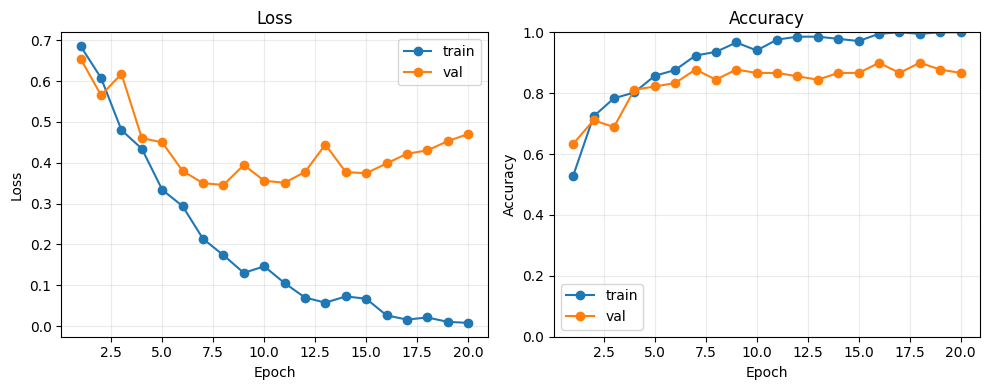

In [10]:
def run_training_experiment(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    test_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    epochs: int = 5,
    plot: bool = True,
) -> tuple[list[dict[str, float]], float, float]:
    history: list[dict[str, float]] = []
    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "val_loss": val_loss,
                "val_acc": val_acc,
            }
        )
        print(
            f"Epoch {epoch:02d}: "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.3f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.3f}"
        )

    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    print(f"Test: loss={test_loss:.4f}, acc={test_acc:.3f}")

    if plot and history:
        plot_training_history(history)

    return history, test_loss, test_acc


history, test_loss, test_acc = run_training_experiment(
    model,
    train_loader,
    val_loader,
    test_loader,
    criterion,
    optimizer,
    device,
    epochs=EPOCHS,
    plot=True,
)

history


## Optional Visualization: Feature Maps Like the AlexNet Notebook

The main lab now uses a simple CNN, so we can visualize feature maps from the trained model directly.

The visualization utility is intentionally styled like the tiled activation-grid view from the referenced AlexNet notebook:

- one tile per channel
- `viridis` colormap
- light gaps between maps
- fixed `vmin` and `vmax` controls so maps are easier to compare

We will inspect stage-1 and stage-2 activations for one seed-specific training image.


Feature-map example for seed 1234: cat -> train/cat/cat_0054.jpg


(<Figure size 1000x1000 with 1 Axes>,
 <Axes: title={'center': 'Simple CNN feature maps after stage 2'}>,
 array([[[0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398],
         ...,
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398]],
 
        [[0.150148, 0.676631, 0.506589],
         [0.143303, 0.669459, 0.511215],
         [0.122312, 0.633153, 0.530398],
         ...,
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398]],
 
        [[0.150148, 0.676631, 0.506589],
         [0.14021 , 0.665859, 0.513427],
         [0.143303, 0.669459, 0.511215],
         ...,
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398],
         [0.122312, 0.633153, 0.530398]],
 
        ...,
 
        [[0.404001, 0.800275, 0.362552],
         [0.575563, 0.844566, 0.256415],
        

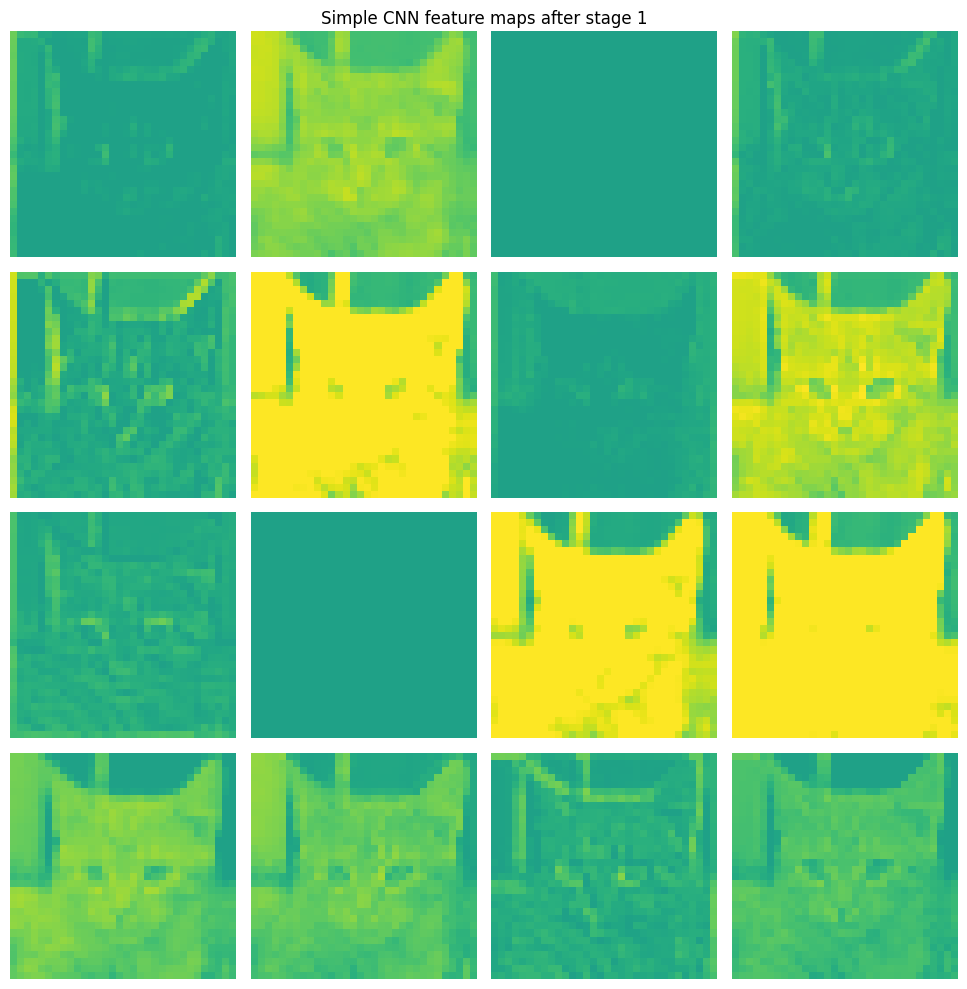

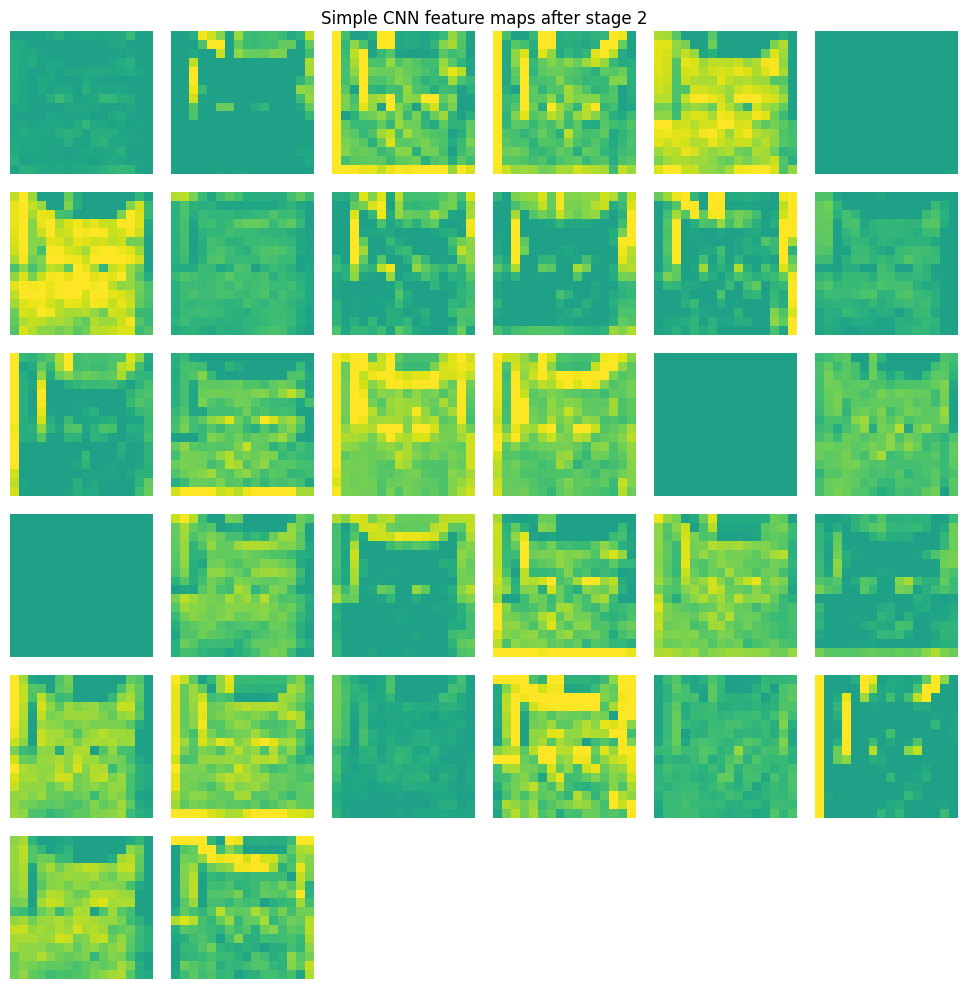

In [11]:
if device is None:
    raise ValueError("Complete Questions 5-9 before visualizing feature maps.")

feature_map_device = device if device is not None else torch.device("cpu")
model = model.to(feature_map_device)
model.eval()

feature_map_index = seed_index(len(train_dataset), offset=500)
feature_map_row = train_df.iloc[feature_map_index]
example_image, _ = train_dataset[feature_map_index]
print(
    f"Feature-map example for seed 1234: "
    f"{feature_map_row['label']} -> {feature_map_row['filepath']}"
)

stage1_maps = extract_feature_maps(
    model.stage1,
    example_image,
    device=feature_map_device,
)
stage2_maps = extract_feature_maps(
    nn.Sequential(model.stage1, model.stage2),
    example_image,
    device=feature_map_device,
)

plot_feature_maps_like_reference(
    stage1_maps,
    title="Simple CNN feature maps after stage 1",
    figsize=(10, 10),
)

plot_feature_maps_like_reference(
    stage2_maps,
    title="Simple CNN feature maps after stage 2",
    figsize=(10, 10),
)


## Optional extension and recap

If you finish early, try one of these:

- increase the filters from `16, 32` to `24, 48`
- add one more convolution block before the classifier
- compare stage-1 and stage-2 feature maps for the same image
- add random horizontal flips to the training data

Recap:

- Which ideas from Labs 1 and 2 showed up again in Lab 3?
- What changed when you moved from NumPy and Pandas into PyTorch?

Then record which change helped validation accuracy most and how the feature maps changed.
